In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
from collections import deque
import random
import matplotlib.pyplot as plt


class QNetwork(nn.Module):
    """Red neuronal que aproxima Q(s,a) para cada accion."""

    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),  # sin activacion — Q puede ser negativo
        )

    def forward(self, x):
        return self.net(x)


# CartPole
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]  # 4 (x, x', θ, θ')
n_actions = env.action_space.n  # 2 (izq, der)

q_net = QNetwork(state_dim, n_actions)
target_net = QNetwork(state_dim, n_actions)
target_net.load_state_dict(q_net.state_dict())  # θ⁻ ← θ

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

# Test: forward pass
s_test = torch.FloatTensor(env.reset()[0]).unsqueeze(0)  # (1, 4)
q_vals = q_net(s_test)
print(f"Q(s, izq)={q_vals[0,0].item():.4f}  Q(s, der)={q_vals[0,1].item():.4f}")

In [ ]:
class ReplayBuffer:
    """Buffer circular FIFO para almacenar transiciones (s,a,r,s',done)."""

    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)  # FIFO automatico

    def push(self, state, action, reward, next_state, done):
        """Agregar una transicion al buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Muestrear batch_size transiciones uniformemente."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
        )

    def __len__(self):
        return len(self.buffer)


# Test
replay = ReplayBuffer(capacity=10_000)
obs, _ = env.reset()
for _ in range(100):
    action = env.action_space.sample()
    obs_next, r, done, _, _ = env.step(action)
    replay.push(obs, action, r, obs_next, float(done))
    obs = obs_next if not done else env.reset()[0]

print(f"Buffer size: {len(replay)}")  # 100
states, actions, rewards, ns, dones = replay.sample(32)
print(f"Batch shapes: {states.shape}, {actions.shape}")  # (32,4), (32,)

In [ ]:
class DQNAgent:
    """Agente DQN completo: Q-Network + Replay Buffer + Target Network."""

    def __init__(
        self,
        state_dim,
        n_actions,
        lr=1e-4,
        gamma=0.99,
        buffer_size=100_000,
        batch_size=64,
        target_update=50,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update
        self.epsilon = epsilon_start
        self.eps_min = epsilon_min
        self.eps_decay = epsilon_decay
        self.step_count = 0

        # Redes y buffer
        self.q_net = QNetwork(state_dim, n_actions)
        self.target_net = QNetwork(state_dim, n_actions)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay = ReplayBuffer(buffer_size)
        self.losses = []

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            return self.q_net(s).argmax().item()

    def push(self, s, a, r, s2, done):
        self.replay.push(s, a, r, s2, done)

    def update(self, double_dqn=False):
        """Un paso de actualizacion de gradiente."""
        if len(self.replay) < self.batch_size:
            return
        states, actions, rewards, next_states, dones = self.replay.sample(
            self.batch_size
        )

        # Q(s,a) de la red online — solo la accion tomada
        q_vals = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            if double_dqn:
                # Double DQN: q_net selecciona, target_net evalua
                best_actions = self.q_net(next_states).argmax(1)
                next_q = (
                    self.target_net(next_states)
                    .gather(1, best_actions.unsqueeze(1))
                    .squeeze(1)
                )
            else:
                # DQN original: target_net selecciona y evalua
                next_q = self.target_net(next_states).max(1).values
            targets = rewards + self.gamma * next_q * (1 - dones)

        loss = torch.nn.functional.mse_loss(q_vals, targets)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.q_net.parameters(), 10)  # gradient change
        self.optimizer.step()
        self.losses.append(loss.item())
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

In [ ]:
def train(agent, env, n_episodes=500, double_dqn=False):
    """Entrenar el agente y recopilar metricas."""
    rewards_hist, epsilons = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        total_r = 0
        while True:
            action = agent.select_action(obs)
            obs_next, r, done, trunc, _ = env.step(action)
            done_for_buffer = done
            agent.push(obs, action, r, obs_next, float(done_for_buffer))
            agent.update(double_dqn=double_dqn)
            obs = obs_next
            total_r += r
            if done or trunc:
                break
        rewards_hist.append(total_r)
        epsilons.append(agent.epsilon)
        if ep % 50 == 0:
            print(
                f"Ep {ep:>4d} | R={total_r:>6.1f} | ε={agent.epsilon:.3f} | loss={np.mean(agent.losses[-50:]) if agent.losses else 0:.4f}"
            )
    return rewards_hist, epsilons


# Entrenar DQN
env = gym.make("CartPole-v1")
agent_dqn = DQNAgent(state_dim=4, n_actions=2)
print("=== Entrenando DQN ===")
rewards_dqn, eps_dqn = train(agent_dqn, env, n_episodes=500, double_dqn=False)

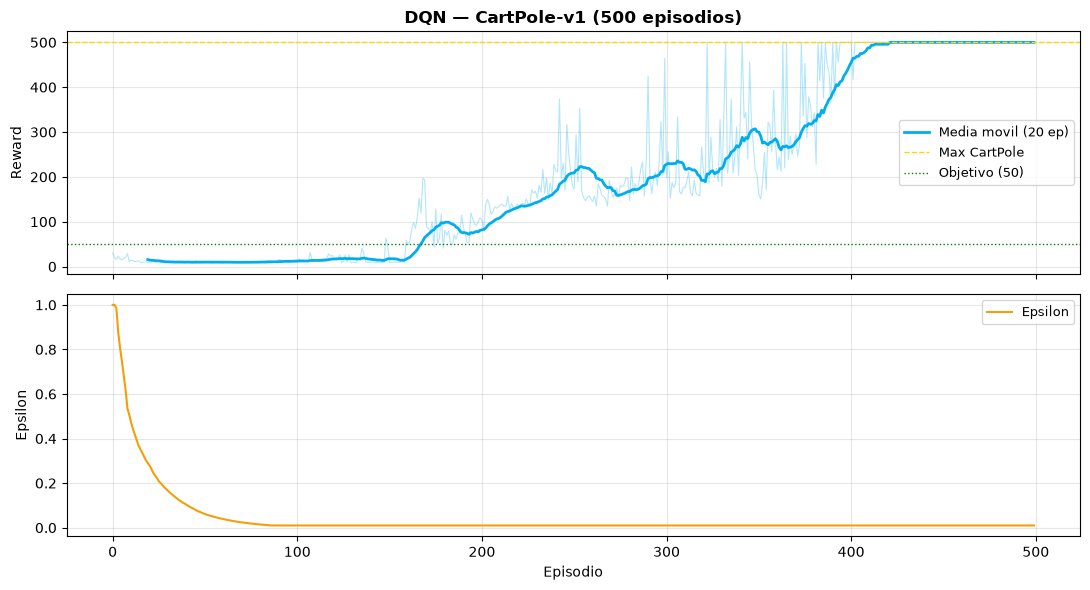

In [5]:
import matplotlib.pyplot as plt


# plt.plot(rewards_dqn)
# plt.plot(eps_dqn)
def plot_training(rewards, epsilons, title="DQN - CartPole-v1"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    window = 20
    ma = np.convolve(rewards, np.ones(window) / window, mode="valid")

    # Reward
    ax1.plot(rewards, alpha=0.3, color="#00AEEF", linewidth=0.8)
    ax1.plot(
        range(window - 1, len(rewards)),
        ma,
        color="#00AEEF",
        linewidth=2,
        label=f"Media movil ({window} ep)",
    )
    ax1.axhline(500, color="gold", linestyle="--", linewidth=1, label="Max CartPole")
    ax1.axhline(50, color="green", linestyle=":", linewidth=1, label="Objetivo (50)")
    ax1.set_ylabel("Reward")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    ax1.set_title(title, fontweight="bold", fontsize=12)

    # Epsilon
    ax2.plot(epsilons, color="#F59E0B", linewidth=1.5, label="Epsilon")
    ax2.set_ylabel("Epsilon")
    ax2.set_xlabel("Episodio")
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training(rewards_dqn, eps_dqn, "DQN — CartPole-v1 (500 episodios)")

In [ ]:
# Entrenar Double DQN - mismo codigo, solo double_dqn=True
agent_ddqn = DQNAgent(state_dim=4, n_actions=2)  # nuevo agente
print("=== Entrenando Double DQN ===")
rewards_ddqn, eps_ddqn = train(agent_ddqn, env, n_episodes=500, double_dqn=True)

# ── Comparacion en una sola figura ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
window = 20
for rewards, label, color in [
    (rewards_dqn, "DQN original", "#00AEEF"),
    (rewards_ddqn, "Double DQN", "#EA580C"),
]:
    ma = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(rewards)), ma, color=color, linewidth=2, label=label)

ax.axhline(500, color="gold", linestyle="--", linewidth=1, label="Max CartPole")
ax.axhline(50, color="gray", linestyle=":", linewidth=1, label="Referencia (50)")
ax.set_xlabel("Episodio")
ax.set_ylabel(f"Reward (media movil {window} ep)")
ax.set_title("DQN vs Double DQN — CartPole-v1", fontweight="bold", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Aumenta `buffer_size` a 100,000 y repite el entrenamiento. ¿Converge más rápido o más lento en las primeras 100 iteraciones? ¿Por qué?**

En las primeras 100 iteraciones ambas curvas siguen bajas y son parecidas; la de buffer 100k mejora un poco más lento. La diferencia se vuelve clara después: la configuración base (`buffer_size=10k`) alcanza el máximo de 500 alrededor del episodio 250, mientras que con 100k el reward se mantiene cerca de 140 durante buena parte del resto del entrenamiento. El buffer grande conserva más experiencias antiguas y tarda más en adaptarse a las transiciones recientes que reflejan la política mejorada.

**Disminuye `target_update` de 200 a 10 (actualizar target casi siempre). ¿El entrenamiento se vuelve más o menos estable? ¿Por qué?**

La gráfica con `target_update=10` es menos estable: el reward sube por tramos y luego cae bruscamente, incluso cerca de cero, antes de recuperarse. Al actualizar la red objetivo con tanta frecuencia, el blanco que persigue la red principal cambia continuamente y favorece oscilaciones. Nota: la pregunta indica 200 como valor inicial, pero el PDF anota 50 para la configuración base; la gráfica disponible muestra la variante 10.

**Prueba `epsilon_decay=0.99` (decae muy rápido). ¿Qué pasa con el reward en los primeros 50 episodios? ¿Y en los últimos 50?**

En los primeros 50 episodios el reward permanece bajo, alrededor de 10–20. En los últimos 50 está cerca del máximo de 500. La gráfica muestra que el reward empieza a crecer con fuerza después de aproximadamente el episodio 200 y llega al máximo hacia el 330. Epsilon decae por paso de gradiente en este notebook, de modo que con 0.99 la exploración disminuye rápidamente.


---

## Ejercicio 1: Ablation Study - Los 2 Trucos de DQN

**Objetivo:** Medir cuantitativamente el impacto de desactivar cada componente estabilizador.

Configuraciones a comparar (entrenar 150 episodios cada una):

1. **Experimento A (Sin Replay Buffer):** Entrenar con `batch_size = 1` y capacidad mínima de buffer (solo la muestra actual).
2. **Experimento B (Sin Target Network):** Sincronizar la target network en cada paso (`target_update = 1`), eliminando el retardo de congelamiento.
3. **Experimento C (DQN Base):** Configuración estándar (`batch_size=64`, `target_update=50`).


In [ ]:
# TODO: Completa el experimento de Ablación y genera la gráfica comparativa con las 3 curvas
print("=== Ejecutando Ablation Study ===")

# 1. Agente Sin Replay (batch_size=1)
# agent_no_replay = DQNAgent(...)

# 2. Agente Sin Target Net (target_update=1)
# agent_no_target = DQNAgent(...)

# 3. Graficar las 3 curvas superpuestas

### Preguntas de Análisis para el Ejercicio 1:

1. _¿Por qué el agente sin Replay Buffer (Experimento A) experimenta inestabilidad y caídas drásticas de recompensa?_
2. _¿Qué ocurre matemáticamente con la pérdida (`loss`) en el Experimento B cuando la red persigue un blanco móvil en cada paso?_
   _(Escribe tu análisis aquí)_


---

## Ejercicio 2: Reto de Arquitectura - Dueling DQN

**Objetivo:** Desacoplar la estimación del valor del estado $V(s)$ de la ventaja de la acción $A(s, a)$:

$$Q(s, a) = V(s) + \left( A(s, a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a') \right)$$


In [ ]:
# TODO: Implementar la arquitectura DuelingQNetwork
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        # 1. Extractor de características compartidas
        self.feature_layer = nn.Sequential(nn.Linear(state_dim, hidden), nn.ReLU())
        # 2. Cabeza de Valor V(s) -> Produce 1 escalar
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1)
        )
        # 3. Cabeza de Ventaja A(s, a) -> Produce n_actions valores
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, n_actions)
        )

    def forward(self, state):
        # features = ...
        # values = ...
        # advantages = ...
        # q_values = values + (advantages - advantages.mean(dim=1, keepdim=True))
        # return q_values
        pass

In [ ]:
# TODO: Entrenar D3QN (Dueling + Double DQN) y comparar contra DQN clásico y Double DQN
# dueling_net = DuelingQNetwork(state_dim=4, n_actions=2)
# agent_d3qn = DQNAgent(state_dim=4, n_actions=2, custom_q_net=dueling_net)
# rewards_d3qn, _ = train(agent_d3qn, env_cartpole, n_episodes=300, double_dqn=True)

# Graficar la comparación de los 3 modelos (DQN vs Double DQN vs D3QN)

---

## Ejercicio 3: Reto de Estabilidad — Soft Updates

En lugar de una sincronización abrupta cada $C$ pasos, actualiza la red objetivo suavemente en cada paso de gradiente:

$$\theta^- \leftarrow \tau \theta + (1 - \tau) \theta^- \quad \text{con } \tau = 0.005$$


In [ ]:
# TODO: Implementar soft_update y comparar la suavidad de la curva de loss frente a Hard Update
def soft_update(target_net, q_net, tau=0.005):
    """Actualización suave continua de Polyak."""
    for target_param, q_param in zip(target_net.parameters(), q_net.parameters()):
        target_param.data.copy_(tau * q_param.data + (1.0 - tau) * target_param.data)


# Evaluar la evolución de 'agent.losses' con Hard Update vs Soft Update:

---

## Reto Extra (Bonus): Escalando a LunarLander-v2

Aplica tu mejor modelo (**D3QN con Soft Updates**) al entorno `LunarLander-v2` (`Gymnasium Box2D`).

- **Observación (8D):** Posición, velocidad lineal, ángulo, velocidad angular y contacto de patas.
- **Acciones (4 discretas):** 0: Nada, 1: Motor izq, 2: Motor principal, 3: Motor der.
- **Meta:** Aterrizar suavemente en la zona designada acumulando $\ge 200$ puntos.


In [ ]:
# Instalación: pip install "gymnasium[box2d]"
# env_lunar = gym.make("LunarLander-v2")
# print("Espacio de observación:", env_lunar.observation_space)
# print("Espacio de acciones:", env_lunar.action_space)

# TODO: Entrena tu agente D3QN en LunarLander-v2 y visualiza su desempeño